In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_original=pd.read_csv("/content/drive/MyDrive/Datasets/adult.csv")
df=df_original.copy()

#EDA

In [4]:
print(df.head())

   39          State-gov   77516   Bachelors   13        Never-married  \
0  50   Self-emp-not-inc   83311   Bachelors   13   Married-civ-spouse   
1  38            Private  215646     HS-grad    9             Divorced   
2  53            Private  234721        11th    7   Married-civ-spouse   
3  28            Private  338409   Bachelors   13   Married-civ-spouse   
4  37            Private  284582     Masters   14   Married-civ-spouse   

         Adm-clerical   Not-in-family   White     Male   2174   0   40  \
0     Exec-managerial         Husband   White     Male      0   0   13   
1   Handlers-cleaners   Not-in-family   White     Male      0   0   40   
2   Handlers-cleaners         Husband   Black     Male      0   0   40   
3      Prof-specialty            Wife   Black   Female      0   0   40   
4     Exec-managerial            Wife   White   Female      0   0   40   

    United-States   <=50K  
0   United-States   <=50K  
1   United-States   <=50K  
2   United-States   <=50K 

In [5]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [6]:
df.columns=col_names

In [7]:
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   50   Self-emp-not-inc   83311   Bachelors             13   
1   38            Private  215646     HS-grad              9   
2   53            Private  234721        11th              7   
3   28            Private  338409   Bachelors             13   
4   37            Private  284582     Masters             14   

        marital_status          occupation    relationship    race      sex  \
0   Married-civ-spouse     Exec-managerial         Husband   White     Male   
1             Divorced   Handlers-cleaners   Not-in-family   White     Male   
2   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
3   Married-civ-spouse      Prof-specialty            Wife   Black   Female   
4   Married-civ-spouse     Exec-managerial            Wife   White   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0             0             0              13   United-States   <=50

In [8]:
df.shape

(32560, 15)

Drop Duplicates if any

In [9]:
df=df.drop_duplicates()

In [10]:
df.shape

(32536, 15)

In [11]:
missing_values=df.isnull().sum()
print(missing_values)

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32536 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32536 non-null  int64 
 1   workclass       32536 non-null  object
 2   fnlwgt          32536 non-null  int64 
 3   education       32536 non-null  object
 4   education_num   32536 non-null  int64 
 5   marital_status  32536 non-null  object
 6   occupation      32536 non-null  object
 7   relationship    32536 non-null  object
 8   race            32536 non-null  object
 9   sex             32536 non-null  object
 10  capital_gain    32536 non-null  int64 
 11  capital_loss    32536 non-null  int64 
 12  hours_per_week  32536 non-null  int64 
 13  native_country  32536 non-null  object
 14  income          32536 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


In [13]:
df['income']=df['income'].str.replace(' ', '', regex=False)

In [14]:
df['income']=df['income'].apply(lambda X:1 if X=='>50K' else 0)

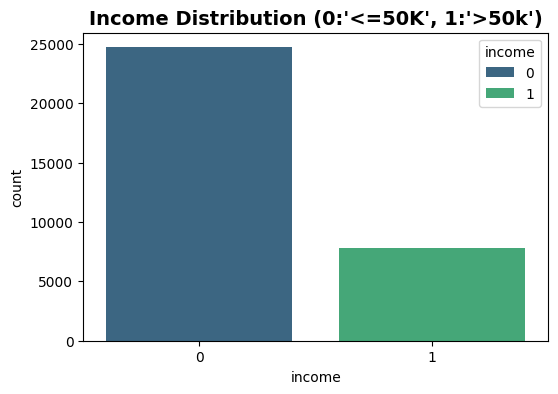

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['income'], palette='viridis', hue=df['income'])
plt.title("Income Distribution (0:'<=50K', 1:'>50k')", fontsize=14, fontweight='bold')
plt.show()

In [16]:
print(df['income'].unique())

[0 1]


In [17]:
num_columns=df.drop(columns=['income']).select_dtypes(include=['int64']).columns.tolist()
print(num_columns)

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [18]:
cat_columns=df.select_dtypes(include=['object']).columns.tolist()
print(cat_columns)

['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


#Feature Engineering

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [20]:
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   50   Self-emp-not-inc   83311   Bachelors             13   
1   38            Private  215646     HS-grad              9   
2   53            Private  234721        11th              7   
3   28            Private  338409   Bachelors             13   
4   37            Private  284582     Masters             14   

        marital_status          occupation    relationship    race      sex  \
0   Married-civ-spouse     Exec-managerial         Husband   White     Male   
1             Divorced   Handlers-cleaners   Not-in-family   White     Male   
2   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
3   Married-civ-spouse      Prof-specialty            Wife   Black   Female   
4   Married-civ-spouse     Exec-managerial            Wife   White   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0             0             0              13   United-States       

In [21]:
Zero_missing_cols=[]

In [22]:
transformers=[]
if Zero_missing_cols:
  impute_then_scale=SklearnPipeline([
      ("Impute", SimpleImputer(strategy='mean')),
      ("Scale", StandardScaler())
  ])
  transformers.append(("Impute_Then_Scale", impute_then_scale, Zero_missing_cols))
  remaining_cols=[c for c in num_columns if c not in Zero_missing_cols]
  if remaining_cols:
    transformers.append(("remaining_cols", SklearnPipeline([("Scaler", StandardScaler())]), remaining_cols))

else:
  transformers.append(("scaler_all", SklearnPipeline([("Scaler", StandardScaler())]), num_columns))


In [23]:
transformers.append(("category_encoder", SklearnPipeline([("cat_encode", OrdinalEncoder())]), cat_columns))

In [24]:
print(transformers)

[('scaler_all', Pipeline(steps=[('Scaler', StandardScaler())]), ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']), ('category_encoder', Pipeline(steps=[('cat_encode', OrdinalEncoder())]), ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country'])]


In [25]:
preprocessor=ColumnTransformer(transformers=transformers, remainder='drop')

In [26]:
X=df.drop(columns=['income'])
y=df['income']

In [27]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
print(f"Train Size:{X_train.shape}")
print(f"Test Size:{X_test.shape}")

Train Size:(26028, 14)
Test Size:(6508, 14)


#Model Training

In [29]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import(accuracy_score, precision_score, recall_score,
                            f1_score, roc_curve, confusion_matrix, classification_report)

In [30]:
gnb=GaussianNB()

In [31]:
pipeline=SklearnPipeline([("preprocessor", preprocessor), ("gnb", gnb)])

In [32]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler_all',
                                                  Pipeline(steps=[('Scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('category_encoder',
                                                  Pipeline(steps=[('cat_encode',
                                                                   OrdinalEncoder())]),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('gnb', GaussianNB())])

In [33]:
y_train_predict=pipeline.predict(X_train)
y_test_predict=pipeline.predict(X_test)

In [34]:
print(f"Train Accuracy:{accuracy_score(y_train, y_train_predict):.4f}")
print(f"Test Accuracy:{accuracy_score(y_test, y_test_predict):.4f}")

Train Accuracy:0.8034
Test Accuracy:0.8070


In [35]:
def calculate_metrics(y_actual, y_pred):
  return {
      "Accuracy_Score":accuracy_score(y_actual, y_pred),
      "Precision_Score":precision_score(y_actual, y_pred, zero_division=0),
      "Recall_Score":recall_score(y_actual, y_pred, zero_division=0),
      "F1-Score":f1_score(y_actual, y_pred, zero_division=0),
      "confusion_matrix":confusion_matrix(y_actual, y_pred),
      "Classification_report":classification_report(y_actual, y_pred, output_dict=True)
  }

In [36]:
result=calculate_metrics(y_test, y_test_predict)

In [37]:
for k, v in result.items():
  if k not in ['confusion_matrix', 'Classification_report']:
    print(f'{k}:{v:.4f}')

Accuracy_Score:0.8070
Precision_Score:0.6970
Recall_Score:0.3520
F1-Score:0.4678


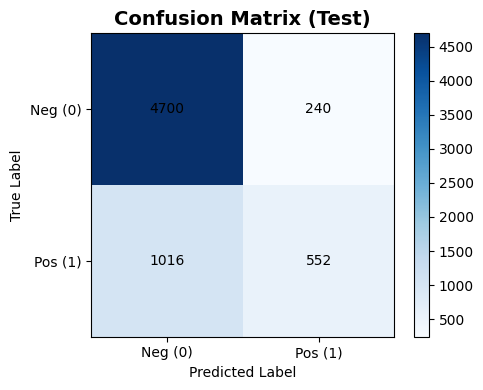

In [38]:
plt.figure(figsize=(5, 4))
test_matrix=result['confusion_matrix']
plt.imshow(test_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix (Test)", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ["Neg (0)", "Pos (1)"])
plt.yticks([0, 1], ["Neg (0)", "Pos (1)"])
for i in range(test_matrix.shape[0]):
  for j in range(test_matrix.shape[1]):
    plt.text(j, i, test_matrix[i, j], ha='center', va='center')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [39]:
y_test_proba=pipeline.predict_proba(X_test)[:, 1]

In [40]:
test_df=X_test.copy()
test_df['actual']=y_test
test_df['predicted']=y_test_predict.tolist()
test_df['proba']=y_test_proba.tolist()

In [41]:
print(test_df.head())

       age          workclass  fnlwgt   education  education_num  \
20335   24            Private  187937   Bachelors             13   
23877   51          Local-gov  387250   Bachelors             13   
19996   72            Private  268861     7th-8th              4   
21440   32   Self-emp-not-inc  180303   Bachelors             13   
10000   23            Private  268145   Bachelors             13   

            marital_status        occupation    relationship  \
20335        Never-married    Prof-specialty       Unmarried   
23877   Married-civ-spouse      Adm-clerical         Husband   
19996              Widowed     Other-service   Not-in-family   
21440             Divorced      Craft-repair       Unmarried   
10000        Never-married   Exec-managerial   Not-in-family   

                      race      sex  capital_gain  capital_loss  \
20335                White   Female             0             0   
23877                White     Male             0             0   
19996

In [42]:
test_df.groupby(["actual", "predicted"]).size()

actual  predicted
0       0            4700
        1             240
1       0            1016
        1             552
dtype: int64

#Save Artifacts

In [43]:
import joblib

In [45]:
joblib.dump(pipeline, "GaussianNB.pkl")
print("Model saved successfully!")

Model saved successfully!


#ROC - Curve

In [46]:
fpr__train, tpr__train, threshold__train=roc_curve(y_train, y_train_predict)
fpr__test, tpr__test, threshold__test=roc_curve(y_test, y_test_predict)

In [47]:
fpr__train, tpr__train, threshold__train

(array([0.        , 0.04874222, 1.        ]),
 array([0.        , 0.33774518, 1.        ]),
 array([inf,  1.,  0.]))

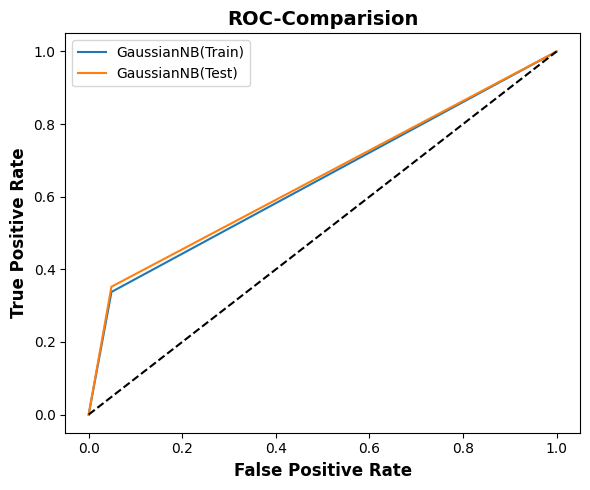

In [51]:
plt.figure(figsize=(6, 5))
plt.plot(fpr__train, tpr__train, label="GaussianNB(Train)")
plt.plot(fpr__test, tpr__test, label="GaussianNB(Test)")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-Comparision", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()